In [1]:
#import any necessary library here
from datascience import *
import numpy as np


In [2]:
%matplotlib inline

In [3]:
#read the file here
jobs = Table.read_table("ai_job_dataset.csv")
jobs.show(5)

job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


In [4]:
#Question 0.1

#How many rows are in this dataset?
#How many columns?

#(Hint: use .num_rows and .num_columns)

In [5]:
#print(jobs.num_rows)
print(jobs.num_columns)

20


🧹 Part 1 – Data Cleaning (20 points)
We will remove columns that are not needed for this project.

Step 1: Remove any unnecessary columns:
Example: 
job_id

posting_date

In [6]:
jobs = jobs.drop(jobs.labels[0]).drop(jobs.labels[15]).drop(jobs.labels[10])
jobs.show(5)

job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,years_experience,industry,application_deadline,job_description_length,benefits_score,company_name
Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-10-31,1132,6.6,TechCorp Inc
Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-09-12,2299,8.5,Cloud AI Solutions
Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-03-28,1329,5.5,Quantum Computing Inc
Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-09-06,1132,6.8,Cognitive Computing
Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-05-09,2011,9.3,Advanced Robotics


In [7]:
#Question 1.1
#How many columns remain after cleaning?

In [8]:
jobs.num_columns
"""17"""

'17'

In [9]:
#Step 2: Keep only Full-Time jobs
#We only want to analyze full-time positions.

#Question 1.2
#Why might we restrict the analysis to full-time jobs?

#(2–3 sentences)

In [10]:
full_time = jobs.where("employment_type", are.equal_to("FT"))
full_time.show(5)

"""We would want to restrict the analysis to only full-time jobs if we were trying to bring in new full-time employees.
To resonable paying ranges for the new hires with other full-time employees at different companies."""

job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,years_experience,industry,application_deadline,job_description_length,benefits_score,company_name
Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-05-09,2011,9.3,Advanced Robotics
Head of AI,168639,AUD,227663,SE,FT,Australia,L,Vietnam,"Spark, SQL, Tableau, Computer Vision, Linux",Associate,9,Consulting,2024-03-17,1497,5.5,TechCorp Inc
Data Scientist,92624,JPY,10188640,MI,FT,Japan,L,Japan,"Kubernetes, SQL, Docker, Deep Learning",Bachelor,4,Government,2024-10-03,1724,9.5,DataVision Ltd
Machine Learning Engineer,215627,GBP,161720,EX,FT,United Kingdom,M,United Kingdom,"Git, Scala, GCP",PhD,10,Government,2025-03-20,902,7.8,DeepTech Ventures
AI Product Manager,20520,USD,20520,EN,FT,India,S,India,"Hadoop, Git, Computer Vision, Kubernetes, Data Visualization",Master,0,Gaming,2024-10-05,2455,7.5,Predictive Systems


'We would want to restrict the analysis to only full-time jobs if we were trying to bring in new full-time employees.\nTo resonable paying ranges for the new hires with other full-time employees at different companies.'

💰 Part 2 – Salary Exploration in USD (20 points)
We will analyze the salary_usd column.

In [11]:
#Step 1: Basic Statistics
#Find:

#Mean salary

#Minimum salary

#Maximum salary

#Question 2.1
#What is the average AI salary (USD)?
#Is the range large or small? What does this suggest?

In [12]:
Ai_jobs = jobs.where("job_title", are.containing("AI")).column("salary_usd")
Avg_AI = np.mean(Ai_jobs)
print(f"This is the average AI salary(USD) ${round(Avg_AI)}")
print(f"This is the largest AI salary(USD) ${max(Ai_jobs)}")
print(f"This is the smallest AI salary(USD) ${min(Ai_jobs)}")

"""The salary range is very large, with the highest paid person making over 20 times the lowest paid.
With significant jumps between the smallest and the average paid, and the average and the largest paid.
This suggests that there is a large range of experience levels and a big displacement in types of jobs and responsibilities."""

This is the average AI salary(USD) $121631
This is the largest AI salary(USD) $410273
This is the smallest AI salary(USD) $16795


'The salary range is very large, with the highest paid person making over 20 times the lowest paid.\nWith significant jumps between the smallest and the average paid, and the average and the largest paid.\nThis suggests that there is a large range of experience levels and a big displacement in types of jobs and responsibilities.'

In [13]:
#Step 2: Histogram
#Create a histogram of salary_usd.

#jobs.hist("salary_usd")
#Question 2.2
#Describe the shape of the distribution:

#Is it symmetric or skewed?

#Are there possible outliers?

'The shape is right skewed, with 400,000 being a possible outlier.'

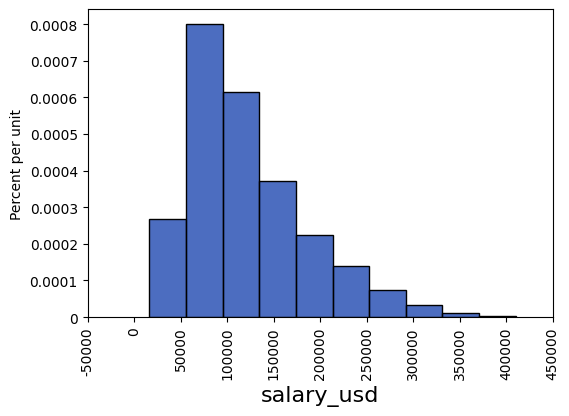

In [14]:
jobs.hist("salary_usd")

"""The shape is right skewed, with 400,000 being a possible outlier."""

🌍 Part 3 – Salary by Country (25 points)
We now compare salaries across countries.

In [15]:
#Step 1: Group by company location
#Step 2: Sort by highest salary
#Step 3: Bar Chart

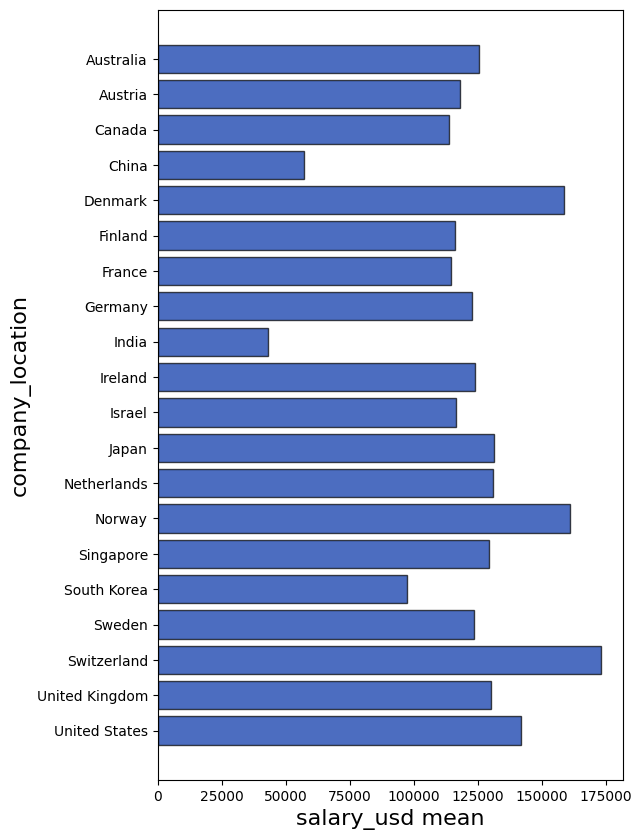

In [16]:
Job_location_salary = jobs.group("company_location", collect = np.mean)
Job_location_salary.barh("company_location", "salary_usd mean")

In [17]:
#Question 3.1
#Which country has the highest average salary?

#Question 3.2
#How does the United States compare to other countries?

#(Write 4–5 sentences interpreting the graph.)

In [18]:
"""Question 3.1: 
The country with the highest average is Switzerland.

Question 3.2: 
The United States is the fourth highest average paid salary compared to the other countries.
The lowest average mean paid is in India. 
The average salary ranges from 50,000 to 175,000.
The table has 20 countries indicated by the rows and the income indicated by the columns. 
The Ordering of countries goes alphabetically."""

'Question 3.1: \nThe country with the highest average is Switzerland.\n\nQuestion 3.2: \nThe United States is the fourth highest average paid salary compared to the other countries.\nThe lowest average mean paid is in India. \nThe average salary ranges from 50,000 to 175,000.\nThe table has 20 countries indicated by the rows and the income indicated by the columns. \nThe Ordering of countries goes alphabetically.'

🌎 Part 4 – Salary in Local Currency (15 points)
Now we explore salaries using salary_local.

In [19]:
#Step 1: Group by country (local salary)

In [20]:
country_local_salary = jobs.select("company_location","salary_local")
country_local_salary.group("company_location", np.mean)

company_location,salary_local mean
Australia,169722
Austria,100546
Canada,142117
China,57285
Denmark,158600
Finland,116267
France,97490.3
Germany,104499
India,43208.6
Ireland,124034


In [21]:
#Question 4.1
#Why is comparing local currency salaries across countries misleading?
#(Think about exchange rates and cost of living.)

In [22]:
"""Many countries use different types of currency, so the different numeric values aren't equivalent to one another. 
The numeric value doesn't reflect the same standard of living or purchasing power across countries."""

"Many countries use different types of currency, so the different numeric values aren't equivalent to one another. \nThe numeric value doesn't reflect the same standard of living or purchasing power across countries."

👩‍💻 Part 5 – Experience Level & Salary (10 points)

In [23]:
#Step 1: Group by experience level
#, experience_salary = jobs.group("experience_level", np.mean)
#experience_salary.barh("experience_level", "salary_usd mean")

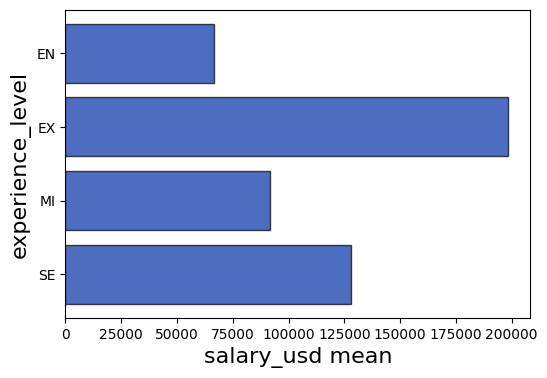

In [24]:
experience_salary = jobs.group("experience_level" ,np.mean)
experience_salary.barh("experience_level", "salary_usd mean")

In [25]:
#Question 5.1
#Does salary increase from Entry (EN) to Executive (EX)?
#Is the increase consistent?

#(3–4 sentences)

In [26]:
"""The salary does increase from Entry (En) to Executive (EX).

The increase is not consistent. The difference from EN to MI is around 30k, and it's the same from MI to SE. From SE to EX is a huge jump of
around 70k. This means that you exponentially make more money the more experience you have. With jobs all paying the same annually when you first
start, gradually increasing until EX, then you begin to make a lot of money."""

"The salary does increase from Entry (En) to Executive (EX).\n\nThe increase is not consistent. The difference from EN to MI is around 30k, and it's the same from MI to SE. From SE to EX is a huge jump of\naround 70k. This means that you exponentially make more money the more experience you have. With jobs all paying the same annually when you first\nstart, gradually increasing until EX, then you begin to make a lot of money."

🏢 Part 6 – Choose Your Own Analysis (15 points)
Choose ONE of the following:

Salary by company size

Salary by employment type

Salary by remote ratio

Salary by industry

Salary by job category

You must:

1. Group the data

2. Create one graph

3. Write a short interpretation (4–6 sentences)

" Based on this graph, Data Engineers make the most amount of money with an average salary well over 120k. \nAll jobs in the industry average salaries bounce around the 120k mark, with some going a little above or below.\nBased on the graph, we can see that there are 20 different types of jobs given this data table.\nThe job that averages the least amount annually is the Data Analyst.\nThis table only shows the types of Jobs and their averages and doesn't take into account the work experience a specific job requires\n, which might show some bias."

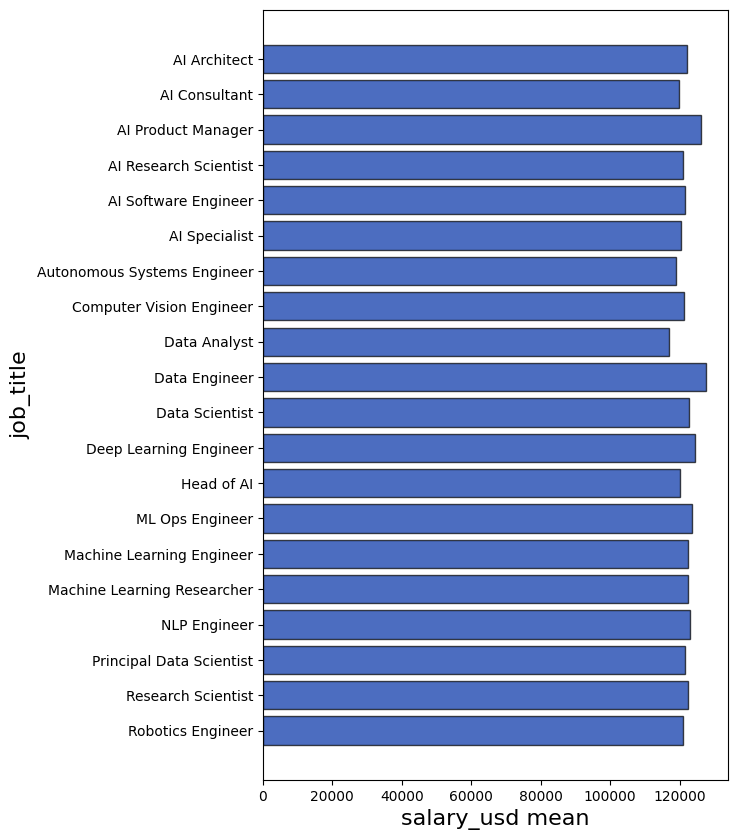

In [27]:
#1. Group the data
company_pay_by_size = jobs.group("job_title" , np.mean)

#2. Create one graph
company_pay_by_size.barh("job_title" , "salary_usd mean")

#3. Write a short interpretation (4–6 sentences)
""" Based on this graph, Data Engineers make the most amount of money with an average salary well over 120k. 
All jobs in the industry average salaries bounce around the 120k mark, with some going a little above or below.
Based on the graph, we can see that there are 20 different types of jobs given this data table.
The job that averages the least amount annually is the Data Analyst.
This table only shows the types of Jobs and their averages and doesn't take into account the work experience a specific job requires
, which might show some bias."""



✍️ Part 7 – Reflection (10 points)
Answer the following:

What factors seem most related to high salary in AI jobs?

What surprised you in this dataset?

What limitations does this dataset have?

(200–300 words)

In [28]:
jobs.where("job_title" , are.containing("AI")).sort("salary_usd" ,descending = True)

"""The factors that seem most related to high salary in AI jobs are the experience level with 
The top salaries in AI are held by executives working at large companies. What suppr 
"""


'The factors that seem most related to high salary in AI jobs are the experience level with \nThe top salaries in AI are held by executives working at large companies. What suppr \n'